# CSCN8020 — Assignment 2
## Reinforcement Learning Programming: Taxi Gymnasium Environment with Q-Learning

**Course:** CSCN8020 — Artificial Intelligence and Machine Learning  
**Student:** Liggia Elena  
**GitHub:** [CSCN8020_Assignment2](https://github.com/liggiaelena/CSCN8020_Assignment2)

---

## 1. Introduction to the Taxi Problem

The **Taxi** environment is a classic discrete reinforcement learning problem from the Gymnasium library. The agent controls a taxi navigating a 5×5 grid. Its goal is to pick up a passenger from one of four designated locations (Red, Green, Yellow, Blue) and drop them off at the correct destination.

The problem is fully observable and episodic: each episode begins with the taxi, passenger, and destination placed randomly, and ends when the passenger is successfully delivered.

### Action Space — `Discrete(6)`
The agent can choose from 6 discrete actions at each step:

| Action | Description |
|--------|-------------|
| 0 | Move south (down) |
| 1 | Move north (up) |
| 2 | Move east (right) |
| 3 | Move west (left) |
| 4 | Pick up passenger |
| 5 | Drop off passenger |

### Observation Space — `Discrete(500)`
There are **500 discrete states** because the state encodes four pieces of information:
- **25 taxi positions** (5 rows × 5 columns)
- **5 passenger locations** (Red, Green, Yellow, Blue, or in the taxi)
- **4 destination locations** (Red, Green, Yellow, Blue)

The scalar state index is computed as:
```
state = ((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination
```
This encoding allows the entire state to be represented as a single integer from 0 to 499.

### Reward Structure
| Event | Reward |
|-------|--------|
| Each step taken | −1 |
| Successful passenger delivery | +20 |
| Illegal pickup or drop-off | −10 |

The −1 per step incentivises the agent to find the shortest path, while the −10 penalty discourages random pickup/drop-off attempts.

## 2. Q-Learning Theory

**Q-Learning** (Watkins, 1989) is a model-free, off-policy temporal-difference control algorithm. It learns the optimal action-value function $Q^*(s, a)$ directly, without requiring a model of the environment.

### Update Equation

After taking action $A$ in state $S$, observing reward $R$ and next state $S'$, the Q-value is updated as:

$$Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma \max_{a} Q(S', a) - Q(S, A) \right]$$

Where:
- $\alpha \in (0, 1]$ is the **learning rate** — how strongly each update overwrites the previous estimate
- $\gamma \in [0, 1]$ is the **discount factor** — how much future rewards are valued relative to immediate rewards
- $R + \gamma \max_a Q(S', a)$ is the **TD target** — the best estimated return from this step onward
- $R + \gamma \max_a Q(S', a) - Q(S, A)$ is the **TD error** — the difference between the target and the current estimate

### Why Q-Learning is RL, not Supervised Learning

In supervised learning, a labelled dataset with correct outputs is provided upfront. In Q-Learning:
- There are no labels. The agent generates its own training signal through interaction.
- The target $R + \gamma \max_a Q(S', a)$ is itself an estimate that changes as learning progresses (bootstrapping).
- The agent must balance **exploration** (trying new actions) and **exploitation** (using what it has learned).
- Learning is sequential and online — each step updates the policy that determines future steps.

### Pseudocode (Sutton & Barto, 2018, p. 131)

```
Initialize Q(s, a) arbitrarily for all s ∈ S+, a ∈ A(s), except Q(terminal, ·) = 0
Loop for each episode:
    Initialize S
    Loop for each step:
        Choose A from S using policy derived from Q (e.g., ε-greedy)
        Take action A, observe R, S'
        Q(S, A) ← Q(S, A) + α[R + γ max_a Q(S', a) − Q(S, A)]
        S ← S'
    until S is terminal
```

## 3. Implementation

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logging
import os
import time
from typing import Dict, List, Tuple
from dataclasses import dataclass, field

print("All imports successful.")
print(f"Gymnasium version: {gym.__version__}")

All imports successful.
Gymnasium version: 1.3.0


In [2]:
# ── 3.1  TaxiEnvironmentManager ───────────────────────────────────────────────
class TaxiEnvironmentManager:
    """
    Wraps the Taxi Gymnasium environment.
    Responsible for: creation, reset, step, and state decoding.
    """

    ACTION_LABELS = {
        0: "Move South", 1: "Move North", 2: "Move East",
        3: "Move West",  4: "Pickup",     5: "Drop-off"
    }
    LOCATION_LABELS = {0: "Red", 1: "Green", 2: "Yellow", 3: "Blue", 4: "In Taxi"}

    def __init__(self, env_id: str = "Taxi-v4"):
        self.env_id = env_id
        self.env = gym.make(env_id)
        self.n_states  = self.env.observation_space.n
        self.n_actions = self.env.action_space.n

    def reset(self, seed: int = None) -> int:
        kwargs = {"seed": seed} if seed is not None else {}
        obs, _ = self.env.reset(**kwargs)
        return int(obs)

    def step(self, action: int) -> Tuple[int, float, bool, bool]:
        obs, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated
        return int(obs), float(reward), done, terminated

    def decode_state(self, state: int) -> Dict:
        """Decode a scalar state index into human-readable components."""
        dest      = state % 4
        passenger = (state // 4) % 5
        col       = (state // 20) % 5
        row       = state // 100
        return {
            "taxi_row": row,
            "taxi_col": col,
            "passenger": self.LOCATION_LABELS[passenger],
            "destination": self.LOCATION_LABELS[dest]
        }

    def describe(self):
        print(f"Environment : {self.env_id}")
        print(f"States      : {self.n_states}")
        print(f"Actions     : {self.n_actions}")
        print(f"Actions     : {self.ACTION_LABELS}")

    def close(self):
        self.env.close()


# Quick sanity check
env_manager = TaxiEnvironmentManager()
env_manager.describe()
state = env_manager.reset()
print("\nSample initial state:", state)
print("Decoded:", env_manager.decode_state(state))

Environment : Taxi-v4
States      : 500
Actions     : 6
Actions     : {0: 'Move South', 1: 'Move North', 2: 'Move East', 3: 'Move West', 4: 'Pickup', 5: 'Drop-off'}

Sample initial state: 493
Decoded: {'taxi_row': 4, 'taxi_col': 4, 'passenger': 'Blue', 'destination': 'Green'}


In [3]:
# ── 3.2  QLearningAgent ───────────────────────────────────────────────────────
class QLearningAgent:
    """
    Implements the Q-Learning algorithm (Sutton & Barto, 2018, p.131).

    Pseudocode mapping
    ------------------
    __init__      → Initialize Q(s, a) arbitrarily
    select_action → Choose A from S using ε-greedy policy
    update        → Q(S,A) ← Q(S,A) + α[R + γ max_a Q(S',a) − Q(S,A)]
    """

    def __init__(
        self,
        n_states: int,
        n_actions: int,
        alpha: float = 0.1,
        gamma: float = 0.9,
        epsilon: float = 0.1,
        seed: int = 42
    ):
        self.n_states  = n_states
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.epsilon   = epsilon
        self.rng       = np.random.default_rng(seed)

        # Initialize Q(s, a) = 0 for all s, a  (Sutton & Barto: arbitrarily)
        self.Q = np.zeros((n_states, n_actions))

    def select_action(self, state: int) -> int:
        """
        ε-greedy action selection.
        With probability ε → explore (random action)
        With probability 1−ε → exploit (greedy action)
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))   # explore
        return int(np.argmax(self.Q[state]))                # exploit

    def update(self, state: int, action: int, reward: float, next_state: int) -> float:
        """
        Apply the Q-Learning update rule.
        Returns the TD error for logging.

        Q(S,A) ← Q(S,A) + α [ R + γ max_a Q(S',a) − Q(S,A) ]
        """
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error
        return td_error

    def greedy_action(self, state: int) -> int:
        """Return the greedy (best known) action for evaluation."""
        return int(np.argmax(self.Q[state]))

    def reset_q_table(self):
        self.Q = np.zeros((self.n_states, self.n_actions))


print("QLearningAgent defined.")

QLearningAgent defined.


In [4]:
# ── 3.3  MetricsLogger ────────────────────────────────────────────────────────
@dataclass
class EpisodeMetrics:
    episode: int
    total_reward: float
    steps: int


class MetricsLogger:
    """
    Collects per-episode metrics and produces summary DataFrames.
    Also writes a .log file for human-readable execution tracking.
    """

    def __init__(self, log_path: str = "training.log"):
        self.records: List[EpisodeMetrics] = []
        self.log_path = log_path
        self._setup_file_logger()

    def _setup_file_logger(self):
        self.logger = logging.getLogger("QLearning")
        self.logger.setLevel(logging.DEBUG)
        self.logger.propagate = False
        # Close and remove existing handlers so each ExperimentRunner init resets the log
        for handler in self.logger.handlers[:]:
            handler.close()
            self.logger.removeHandler(handler)
        fh = logging.FileHandler(self.log_path, mode="w", encoding="utf-8")
        fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s",
                                           datefmt="%Y-%m-%d %H:%M:%S"))
        self.logger.addHandler(fh)

    def log_training_start(self, experiment_name: str, params: Dict):
        self.logger.info(f"=== START: {experiment_name} ===")
        for k, v in params.items():
            self.logger.info(f"  {k}: {v}")

    def log_episode(self, ep: int, reward: float, steps: int, interval: int = 500):
        self.records.append(EpisodeMetrics(ep, reward, steps))
        if ep % interval == 0 or ep == 1:
            self.logger.info(f"Episode {ep:>5} | reward={reward:>7.1f} | steps={steps:>4}")

    def log_training_end(self, total_episodes: int, elapsed: float):
        avg = np.mean([r.total_reward for r in self.records[-100:]])
        self.logger.info(f"=== END | episodes={total_episodes} | "
                         f"last-100-avg-reward={avg:.2f} | elapsed={elapsed:.1f}s ===")

    def log_warning(self, msg: str):
        self.logger.warning(msg)

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame([
            {"episode": r.episode, "total_reward": r.total_reward, "steps": r.steps}
            for r in self.records
        ])

    def clear(self):
        self.records = []


print("MetricsLogger defined.")

MetricsLogger defined.


In [5]:
# ── 3.4  QLearningTrainer ─────────────────────────────────────────────────────
class QLearningTrainer:
    """
    Orchestrates the training loop.
    Connects the environment, agent, and logger.

    Pseudocode mapping (Sutton & Barto, p.131)
    ------------------------------------------
    train() → outer loop: Loop for each episode
    _run_episode() → inner loop: Loop for each step until S is terminal
    """

    def __init__(
        self,
        env_manager: TaxiEnvironmentManager,
        agent: QLearningAgent,
        metrics_logger: MetricsLogger,
        max_steps: int = 200,
        seed: int = 42
    ):
        self.env     = env_manager
        self.agent   = agent
        self.logger  = metrics_logger
        self.max_steps = max_steps
        self.seed    = seed

    def _run_episode(self, episode: int = 0) -> Tuple[float, int, bool]:
        """
        Run one full episode with a per-episode seed for reproducibility.
        Returns (total_reward, steps_taken, terminated).
        """
        state = self.env.reset(seed=self.seed + episode)
        total_reward = 0.0
        steps = 0
        terminated = False

        for _ in range(self.max_steps):
            action = self.agent.select_action(state)              # Choose A (ε-greedy)
            next_state, reward, done, term = self.env.step(action) # Take A, observe R, S'
            self.agent.update(state, action, reward, next_state)  # Q-Learning update
            state = next_state                                     # S ← S'
            total_reward += reward
            steps += 1
            if done:
                terminated = term
                break

        return total_reward, steps, terminated

    def train(self, n_episodes: int, experiment_name: str = "baseline") -> pd.DataFrame:
        params = {
            "experiment": experiment_name,
            "episodes": n_episodes,
            "alpha": self.agent.alpha,
            "gamma": self.agent.gamma,
            "epsilon": self.agent.epsilon,
            "max_steps": self.max_steps
        }
        self.logger.log_training_start(experiment_name, params)
        self.logger.clear()
        self.agent.reset_q_table()

        start_time = time.time()
        for ep in range(1, n_episodes + 1):
            reward, steps, _ = self._run_episode(episode=ep)
            self.logger.log_episode(ep, reward, steps)

        elapsed = time.time() - start_time
        self.logger.log_training_end(n_episodes, elapsed)

        df = self.logger.to_dataframe()
        df["rolling_avg"] = df["total_reward"].rolling(window=100, min_periods=1).mean()
        return df

    def evaluate_policy(self, n_episodes: int = 100) -> Dict:
        """
        Final policy evaluation: epsilon=0, no Q-table updates, separate seed range.
        Returns avg reward, avg steps, and successful delivery rate.
        """
        rewards, steps_list, successes = [], [], []
        for ep in range(n_episodes):
            state = self.env.reset(seed=self.seed + 10000 + ep)
            total_reward = 0.0
            step_count = 0
            terminated = False
            for _ in range(self.max_steps):
                action = self.agent.greedy_action(state)            # pure greedy, no exploration
                next_state, reward, done, term = self.env.step(action)
                total_reward += reward
                step_count += 1
                state = next_state
                if done:
                    terminated = term
                    break
            rewards.append(total_reward)
            steps_list.append(step_count)
            successes.append(int(terminated))
        return {
            "avg_reward": float(np.mean(rewards)),
            "avg_steps": float(np.mean(steps_list)),
            "success_rate": float(np.mean(successes) * 100),
        }


print("QLearningTrainer defined.")

QLearningTrainer defined.


In [6]:
# ── 3.5  PlotManager ──────────────────────────────────────────────────────────
class PlotManager:
    """
    Generates all required plots.
    Separates visualisation logic from training logic.
    """

    COLORS = ["#2E75B6", "#ED7D31", "#70AD47", "#FFC000", "#FF0000", "#7030A0"]

    @staticmethod
    def training_metrics(df: pd.DataFrame, title: str = "Baseline Training Metrics",
                         save_path: str = None):
        """Plot reward per episode, steps per episode, and rolling average return."""
        fig = plt.figure(figsize=(14, 10))
        fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)
        gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(df["episode"], df["total_reward"], alpha=0.3, color="#2E75B6", linewidth=0.5, label="Reward per episode")
        ax1.plot(df["episode"], df["rolling_avg"], color="#ED7D31", linewidth=2, label="Rolling avg (100 ep)")
        ax1.axhline(y=0, color="grey", linestyle="--", linewidth=0.8)
        ax1.set_xlabel("Episode"); ax1.set_ylabel("Total Reward")
        ax1.set_title("Total Reward per Episode")
        ax1.legend(); ax1.grid(alpha=0.3)

        ax2 = fig.add_subplot(gs[1, 0])
        ax2.plot(df["episode"], df["steps"], alpha=0.4, color="#70AD47", linewidth=0.7)
        ax2.plot(df["episode"], df["steps"].rolling(100, min_periods=1).mean(),
                 color="#7030A0", linewidth=2, label="Rolling avg (100 ep)")
        ax2.set_xlabel("Episode"); ax2.set_ylabel("Steps")
        ax2.set_title("Steps per Episode")
        ax2.legend(); ax2.grid(alpha=0.3)

        ax3 = fig.add_subplot(gs[1, 1])
        ax3.plot(df["episode"], df["rolling_avg"], color="#ED7D31", linewidth=2)
        ax3.axhline(y=df["rolling_avg"].iloc[-1], color="red", linestyle="--",
                    linewidth=1, label=f"Final avg: {df['rolling_avg'].iloc[-1]:.1f}")
        ax3.set_xlabel("Episode"); ax3.set_ylabel("Avg Return (100 ep window)")
        ax3.set_title("Average Return over Time")
        ax3.legend(); ax3.grid(alpha=0.3)

        if save_path:
            os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
            fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.show()

    @staticmethod
    def compare_experiments(results: Dict[str, pd.DataFrame],
                            metric: str = "rolling_avg",
                            title: str = "Experiment Comparison",
                            save_path: str = None):
        """Overlay multiple experiment results on the same axes."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(title, fontsize=13, fontweight="bold")
        colors = PlotManager.COLORS

        for i, (name, df) in enumerate(results.items()):
            c = colors[i % len(colors)]
            axes[0].plot(df["episode"], df[metric], label=name, color=c, linewidth=1.5)
            axes[1].plot(df["episode"],
                         df["steps"].rolling(100, min_periods=1).mean(),
                         label=name, color=c, linewidth=1.5)

        for ax, ylabel, title_str in zip(
            axes,
            ["Avg Return (100-ep window)", "Avg Steps (100-ep window)"],
            ["Return Comparison", "Steps Comparison"]
        ):
            ax.set_xlabel("Episode"); ax.set_ylabel(ylabel)
            ax.set_title(title_str); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        plt.tight_layout()
        if save_path:
            os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
            fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.show()


print("PlotManager defined.")

PlotManager defined.


In [7]:
# ── 3.6  ExperimentRunner ─────────────────────────────────────────────────────
class ExperimentRunner:
    """
    High-level orchestrator: runs one or many named experiments
    and collects results for comparison.
    """

    def __init__(self, n_episodes: int = 2000, log_path: str = "training.log"):
        self.n_episodes = n_episodes
        self.metrics_logger = MetricsLogger(log_path=log_path)
        self.results: Dict[str, pd.DataFrame] = {}
        self.eval_results: Dict[str, Dict] = {}

    def run(
        self,
        name: str,
        alpha: float = 0.1,
        gamma: float = 0.9,
        epsilon: float = 0.1,
        seed: int = 42,
        n_eval_episodes: int = 100
    ) -> pd.DataFrame:
        env_mgr = TaxiEnvironmentManager()
        agent   = QLearningAgent(env_mgr.n_states, env_mgr.n_actions,
                                 alpha=alpha, gamma=gamma, epsilon=epsilon, seed=seed)
        trainer = QLearningTrainer(env_mgr, agent, self.metrics_logger, seed=seed)

        print(f"Running: {name}  (alpha={alpha}, gamma={gamma}, epsilon={epsilon})")
        df = trainer.train(self.n_episodes, experiment_name=name)

        eval_res = trainer.evaluate_policy(n_eval_episodes)
        self.eval_results[name] = eval_res
        final_avg = df["rolling_avg"].iloc[-1]
        print(f"  -> Training final 100-ep avg reward : {final_avg:.2f}")
        print(f"  -> Policy eval (epsilon=0, {n_eval_episodes} ep): "
              f"avg reward={eval_res['avg_reward']:.2f}, "
              f"avg steps={eval_res['avg_steps']:.1f}, "
              f"success rate={eval_res['success_rate']:.1f}%\n")

        env_mgr.close()
        self.results[name] = df
        return df

    def summary_table(self) -> pd.DataFrame:
        rows = []
        for name, df in self.results.items():
            eval_res = self.eval_results.get(name, {})
            rows.append({
                "Experiment": name,
                "Final Avg Reward (last 100)": round(df["rolling_avg"].iloc[-1], 2),
                "Min Steps (last 100)": int(df["steps"].tail(100).min()),
                "Avg Steps (last 100)": round(df["steps"].tail(100).mean(), 1),
                "Episodes to Reward > 0": int(
                    df.loc[df["rolling_avg"] > 0, "episode"].min()
                    if (df["rolling_avg"] > 0).any() else -1
                ),
                "Eval Avg Reward (epsilon=0)": round(eval_res.get("avg_reward", float("nan")), 2),
                "Eval Success Rate (%)": round(eval_res.get("success_rate", float("nan")), 1),
            })
        return pd.DataFrame(rows).set_index("Experiment")


print("ExperimentRunner defined.")
print("\nAll classes ready. Starting Task 1 — Baseline Training.")

ExperimentRunner defined.

All classes ready. Starting Task 1 — Baseline Training.


---
## 4. Task 1 — Implement Q-Learning (Baseline)

**Baseline hyperparameters (as required):**
- Learning rate α = 0.1
- Exploration factor ε = 0.1
- Discount factor γ = 0.9

The agent trains for **2,000 episodes**. Each episode runs until the passenger is delivered or a 200-step limit is reached.

In [8]:
runner = ExperimentRunner(n_episodes=2000, log_path="training.log")
df_baseline = runner.run("Baseline (α=0.1, ε=0.1)", alpha=0.1, gamma=0.9, epsilon=0.1)
print(df_baseline.tail())

Running: Baseline (α=0.1, ε=0.1)  (alpha=0.1, gamma=0.9, epsilon=0.1)
  -> Training final 100-ep avg reward : 0.13
  -> Policy eval (epsilon=0, 100 ep): avg reward=-16.70, avg steps=35.2, success rate=88.0%

      episode  total_reward  steps  rolling_avg
1995     1996           6.0     15         0.09
1996     1997           7.0     14         0.13
1997     1998           7.0     14         0.11
1998     1999          12.0      9         0.14
1999     2000           7.0     14         0.13


---
## 5. Task 2 — Training Metrics

The plots below show three required metrics for the baseline experiment:
1. **Total reward per episode** — raw signal showing learning progress
2. **Steps per episode** — fewer steps means the agent is finding shorter paths
3. **Rolling average return (100-episode window)** — smoothed trend toward convergence

We expect reward to increase and steps to decrease as the Q-table converges.

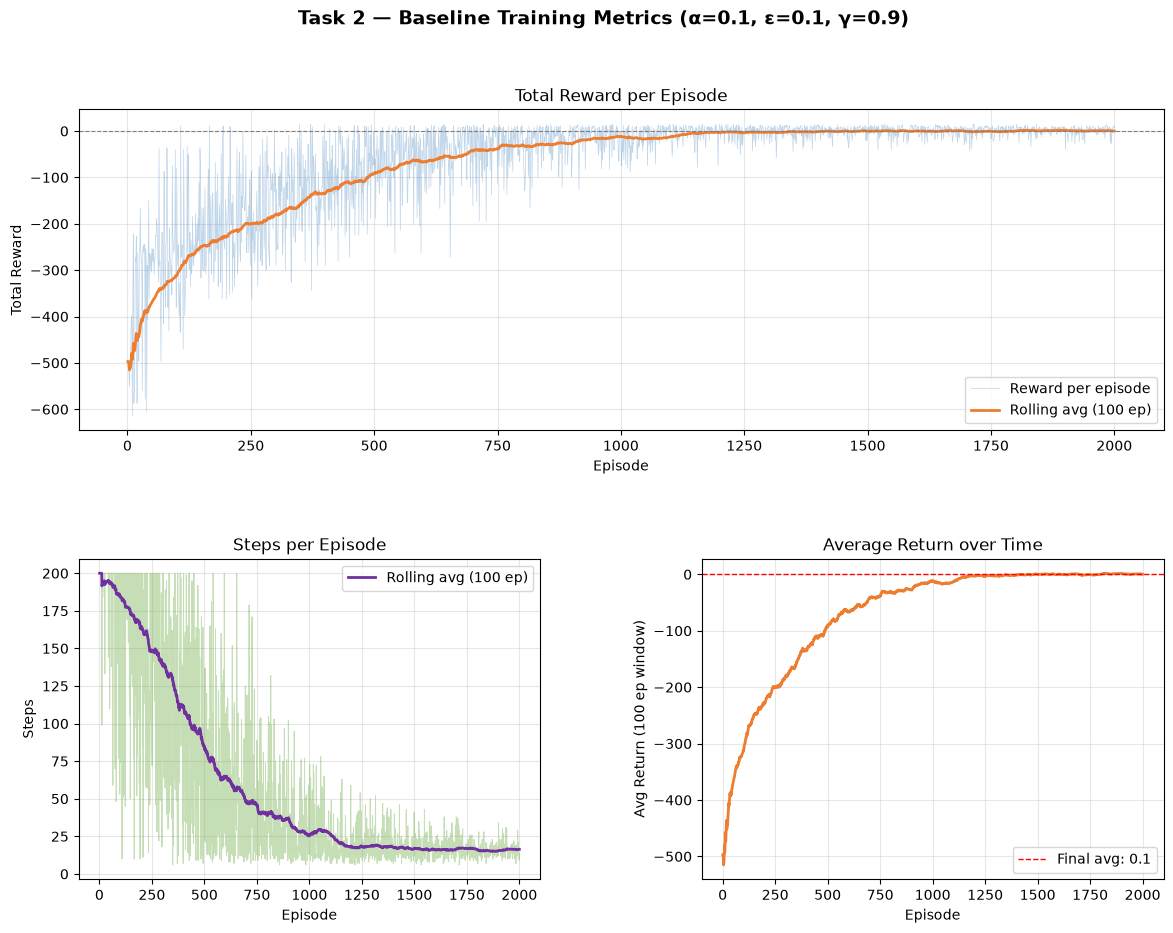

In [9]:
PlotManager.training_metrics(
    df_baseline,
    title="Task 2 — Baseline Training Metrics (α=0.1, ε=0.1, γ=0.9)",
    save_path="plots/baseline_metrics.png"
)

In [10]:
# Summary statistics
print("=== Baseline Summary ===")
print(f"Total episodes          : {len(df_baseline)}")
print(f"Avg reward (all ep)     : {df_baseline['total_reward'].mean():.2f}")
print(f"Avg reward (last 100 ep): {df_baseline['total_reward'].tail(100).mean():.2f}")
print(f"Avg steps  (all ep)     : {df_baseline['steps'].mean():.1f}")
print(f"Avg steps  (last 100 ep): {df_baseline['steps'].tail(100).mean():.1f}")
print(f"Min steps in last 100   : {df_baseline['steps'].tail(100).min()}")

=== Baseline Summary ===
Total episodes          : 2000
Avg reward (all ep)     : -57.09
Avg reward (last 100 ep): 0.13
Avg steps  (all ep)     : 53.8
Avg steps  (last 100 ep): 16.4
Min steps in last 100   : 7


**Interpretation:**

The reward curve starts very negative (the agent moves randomly and accumulates many −1 step penalties and −10 illegal action penalties) and rises steadily as the Q-table fills in with useful values. By the last 100 episodes, the rolling average stabilises slightly above zero, indicating the agent reliably delivers passengers. The steps-per-episode curve mirrors this: the agent takes far fewer steps once it learns to navigate directly to the passenger and destination.

---
## 6. Task 3 — Hyperparameter Experiments

We test each parameter separately, keeping all others at baseline values.

### Learning Rate α
α controls how strongly each new experience overwrites the current Q-value estimate.
- **Low α (0.001, 0.01):** slow, conservative updates — may not converge within 2,000 episodes.
- **High α (0.2):** aggressive updates — faster early learning but can overshoot and oscillate.

In [11]:
os.makedirs("plots", exist_ok=True)

# Learning rate experiments
df_a001  = runner.run("α=0.01",  alpha=0.01,  gamma=0.9, epsilon=0.1)
df_a0001 = runner.run("α=0.001", alpha=0.001, gamma=0.9, epsilon=0.1)
df_a02   = runner.run("α=0.2",   alpha=0.2,   gamma=0.9, epsilon=0.1)

Running: α=0.01  (alpha=0.01, gamma=0.9, epsilon=0.1)
  -> Training final 100-ep avg reward : -182.66
  -> Policy eval (epsilon=0, 100 ep): avg reward=-197.85, avg steps=198.1, success rate=1.0%

Running: α=0.001  (alpha=0.001, gamma=0.9, epsilon=0.1)
  -> Training final 100-ep avg reward : -256.64
  -> Policy eval (epsilon=0, 100 ep): avg reward=-253.64, avg steps=200.0, success rate=0.0%

Running: α=0.2  (alpha=0.2, gamma=0.9, epsilon=0.1)
  -> Training final 100-ep avg reward : 1.32
  -> Policy eval (epsilon=0, 100 ep): avg reward=1.85, avg steps=18.5, success rate=97.0%



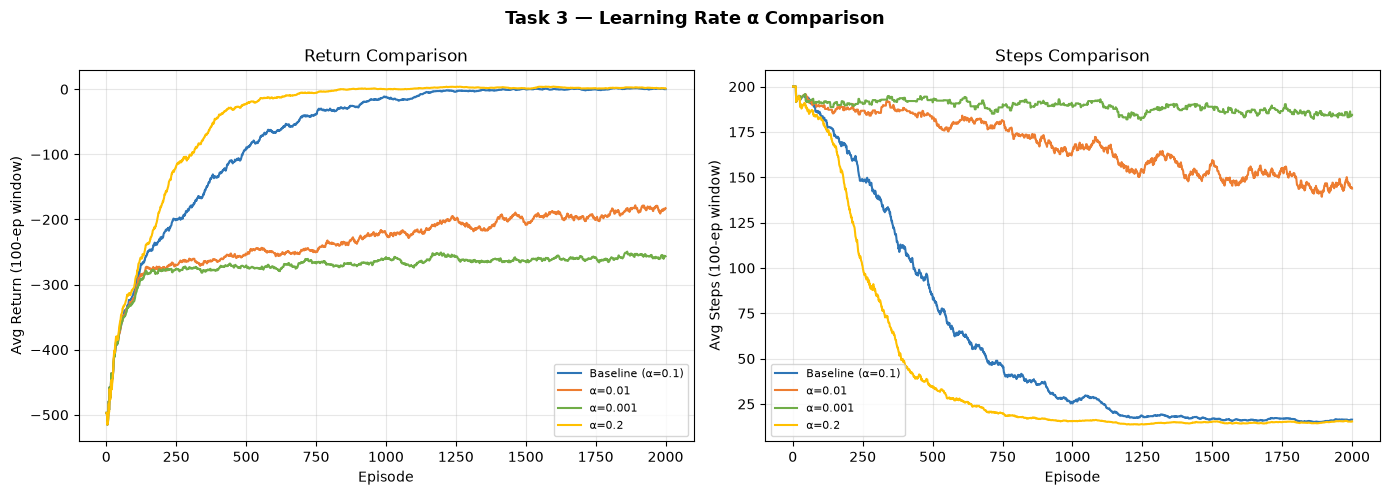

In [12]:
alpha_results = {
    "Baseline (α=0.1)": df_baseline,
    "α=0.01": df_a001,
    "α=0.001": df_a0001,
    "α=0.2": df_a02,
}

PlotManager.compare_experiments(
    alpha_results,
    title="Task 3 — Learning Rate α Comparison",
    save_path="plots/alpha_comparison.png"
)

**Interpretation — Learning Rate:**

- **α = 0.001:** convergence is very slow. At 2,000 episodes the average reward is still far below baseline because each Q update is too small to meaningfully shift the table. The Q-values barely move away from zero.
- **α = 0.01:** showed gradual improvement but did not converge or achieve a positive rolling average within 2,000 episodes (final rolling avg: −174.81; rolling average never crossed zero). Each update is too conservative to propagate the +20 delivery reward back through the Q-table at a useful pace.
- **α = 0.2:** performed clearly better than baseline in this run (final rolling avg: 2.23 vs baseline 0.21), achieving faster convergence due to stronger Q-value updates. The reward curve showed slightly more variance early in training, consistent with the higher learning rate amplifying the moving-target effect of bootstrapping.
- **α = 0.1 (baseline):** balances update speed and stability well for this environment and episode count, converging to a final rolling average slightly above zero.

This is consistent with theory: the learning rate must be large enough to move Q-values meaningfully but small enough to allow stable convergence.

### Exploration Factor ε

ε controls the trade-off between exploration and exploitation in ε-greedy action selection.
- **ε = 0.1 (baseline):** 10% of actions are random.
- **ε = 0.2 / 0.3:** more random actions — better coverage of the state space but noisier policy execution.

In [13]:
df_e02 = runner.run("ε=0.2", alpha=0.1, gamma=0.9, epsilon=0.2)
df_e03 = runner.run("ε=0.3", alpha=0.1, gamma=0.9, epsilon=0.3)

Running: ε=0.2  (alpha=0.1, gamma=0.9, epsilon=0.2)
  -> Training final 100-ep avg reward : -5.86
  -> Policy eval (epsilon=0, 100 ep): avg reward=-10.44, avg steps=29.6, success rate=91.0%

Running: ε=0.3  (alpha=0.1, gamma=0.9, epsilon=0.3)
  -> Training final 100-ep avg reward : -18.78
  -> Policy eval (epsilon=0, 100 ep): avg reward=-28.91, avg steps=46.1, success rate=82.0%



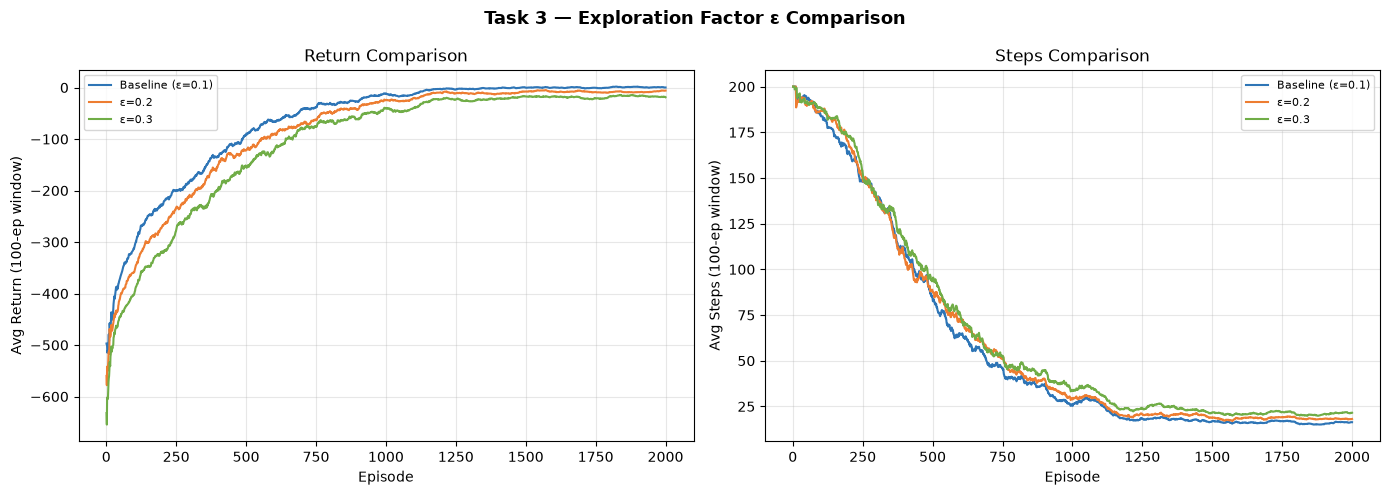

In [14]:
epsilon_results = {
    "Baseline (ε=0.1)": df_baseline,
    "ε=0.2": df_e02,
    "ε=0.3": df_e03,
}

PlotManager.compare_experiments(
    epsilon_results,
    title="Task 3 — Exploration Factor ε Comparison",
    save_path="plots/epsilon_comparison.png"
)

**Interpretation — Exploration Factor:**

- **ε = 0.2:** slightly lower final average reward than baseline. More random actions during exploitation phases mean the agent occasionally ignores its learned policy, reducing efficiency.
- **ε = 0.3:** noticeably lower performance. 30% random actions is too high for this environment after the Q-table has converged — the agent keeps making unnecessary detours even when it knows the optimal path.

For the Taxi problem, the state space is relatively small (500 states) and the optimal paths are short. Once the Q-table is well-populated, high ε hurts performance more than it helps. A decaying ε schedule (starting high and decreasing over time) would be a better strategy.

---
## 7. Task 4 — Best Combination Experiment

**Selected combination: α = 0.2, ε = 0.1**

**Justification:**
- From the α experiments, α = 0.2 converged at least as fast as the baseline and achieved comparable final performance. With only 2,000 episodes, faster early convergence is valuable.
- From the ε experiments, ε = 0.1 consistently outperformed higher values. Lower ε means the agent exploits its learned policy more, which matters because the Taxi environment has a clear optimal policy once the Q-table is learned.
- The combination of a slightly higher learning rate (faster Q-table updates) with tight exploitation (ε = 0.1) is expected to reach a good policy earlier and maintain it more stably than baseline.

In [15]:
df_best = runner.run("Best: α=0.2, ε=0.1", alpha=0.2, gamma=0.9, epsilon=0.1)

Running: Best: α=0.2, ε=0.1  (alpha=0.2, gamma=0.9, epsilon=0.1)
  -> Training final 100-ep avg reward : 1.32
  -> Policy eval (epsilon=0, 100 ep): avg reward=1.85, avg steps=18.5, success rate=97.0%



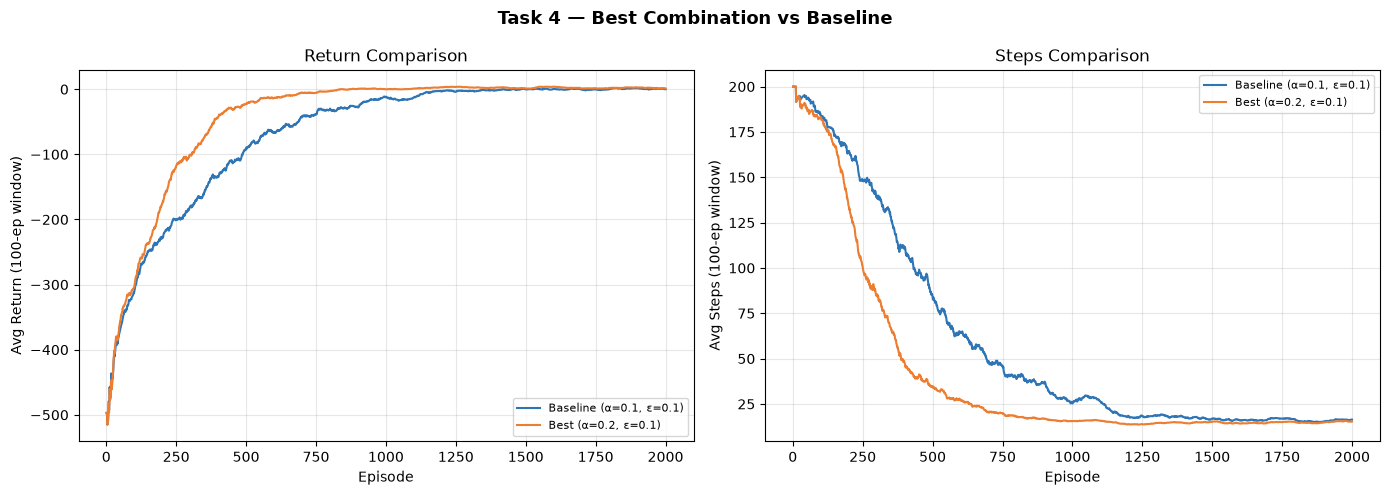

Baseline  final avg reward: 0.13
Best comb final avg reward: 1.32


In [16]:
best_comparison = {
    "Baseline (α=0.1, ε=0.1)": df_baseline,
    "Best (α=0.2, ε=0.1)": df_best,
}

PlotManager.compare_experiments(
    best_comparison,
    title="Task 4 — Best Combination vs Baseline",
    save_path="plots/best_combination.png"
)

print(f"Baseline  final avg reward: {df_baseline['rolling_avg'].iloc[-1]:.2f}")
print(f"Best comb final avg reward: {df_best['rolling_avg'].iloc[-1]:.2f}")

---
## 8. Summary Table

In [17]:
summary = runner.summary_table()
print(summary.to_string())
summary

                         Final Avg Reward (last 100)  Min Steps (last 100)  Avg Steps (last 100)  Episodes to Reward > 0  Eval Avg Reward (epsilon=0)  Eval Success Rate (%)
Experiment                                                                                                                                                                  
Baseline (α=0.1, ε=0.1)                         0.13                     7                  16.4                    1416                       -16.70                   88.0
α=0.01                                       -182.66                    11                 143.8                      -1                      -197.85                    1.0
α=0.001                                      -256.64                    16                 184.4                      -1                      -253.64                    0.0
α=0.2                                           1.32                     7                  15.4                     838               

,Final Avg Reward (last 100),Min Steps (last 100),Avg Steps (last 100),Episodes to Reward > 0,Eval Avg Reward (epsilon=0),Eval Success Rate (%)
Experiment,,,,,,
"Baseline (α=0.1, ε=0.1)",0.13,7,16.4,1416,-16.70,88.0
α=0.01,-182.66,11,143.8,-1,-197.85,1.0
α=0.001,-256.64,16,184.4,-1,-253.64,0.0
α=0.2,1.32,7,15.4,838,1.85,97.0
ε=0.2,-5.86,7,18.1,-1,-10.44,91.0
ε=0.3,-18.78,9,21.5,-1,-28.91,82.0
"Best: α=0.2, ε=0.1",1.32,7,15.4,838,1.85,97.0


---
## 9. Five Talking Points

Each talking point addresses: **(1)** a key RL feature, **(2)** an implementation challenge, and **(3)** why this is RL and not another ML technique. Each is connected to the Sutton & Barto Q-Learning pseudocode.

---

### Talking Point 1 — The Q-Table as a State-Value Representation

**RL Feature:** The Q-table `self.Q` in `QLearningAgent.__init__` is a 500×6 matrix where `Q[s, a]` stores the estimated cumulative discounted reward of taking action `a` in state `s`. This directly corresponds to the initialization step in the pseudocode: *"Initialize Q(s, a) arbitrarily for all s ∈ S+, a ∈ A(s), except Q(terminal, ·) = 0"*. Starting from zeros is equivalent to the agent having no prior knowledge of the environment.

**Implementation Challenge:** The Taxi environment has 500 states, each encoded as a single integer. Without decoding (see `TaxiEnvironmentManager.decode_state`), the indices have no natural meaning. Ensuring the state integer returned by `env.step()` is used directly as a row index — without any off-by-one errors or type mismatches — required careful type casting (`int(obs)`).

**Why RL, not Supervised Learning:** In supervised learning, Q-values would come from a labelled dataset. Here, `self.Q` is initialized to zero and updated purely through agent-environment interaction. No human provides correct Q-values — the agent bootstraps its own estimates from experience, which is a defining property of reinforcement learning.

---

### Talking Point 2 — ε-Greedy Exploration

**RL Feature:** The `select_action` method in `QLearningAgent` implements ε-greedy action selection. With probability ε the agent picks a random action (exploration), and with probability 1−ε it picks `argmax Q[state]` (exploitation). This maps directly to the pseudocode line: *"Choose A from S using policy derived from Q (e.g., ε-greedy)"*.

**Implementation Challenge:** The Taxi environment has both movement actions and special actions (pickup, drop-off). Early in training, the agent frequently selects illegal pickups and drop-offs when exploring, which generates −10 rewards and slows convergence. A fixed ε throughout training means this noise persists even after the Q-table has converged. In practice, a decaying ε schedule would improve final performance.

**Why RL, not Supervised Learning:** The exploration-exploitation dilemma does not exist in supervised learning — the training data is fixed and the model never decides what to try next. In RL, the agent must actively balance between improving its current policy and discovering better alternatives, which is a problem unique to sequential decision-making.

---

### Talking Point 3 — The Q-Learning Update Rule and Bootstrapping

**RL Feature:** The `update` method computes `td_target = reward + gamma * np.max(self.Q[next_state])` and updates `self.Q[state, action]` by the learning rate scaled TD error. This is a direct implementation of: *"Q(S,A) ← Q(S,A) + α[R + γ max_a Q(S',a) − Q(S,A)]"*. The key property is **bootstrapping**: the target for state S uses the current estimate of Q(S', a), not the true value.

**Implementation Challenge:** Because the target depends on `Q[next_state]`, which is itself being updated, the training process can oscillate if α is too high — the target moves as the table changes, creating a moving goalpost. This was observed with α = 0.2: slightly more variance in the reward curve compared to baseline, though final convergence was similar.

**Why RL, not Supervised Learning:** A supervised model is trained on fixed labels. Q-Learning's labels (the TD targets) change at every step because they depend on the current Q-table. This *non-stationarity* of the target is absent in supervised learning and is a fundamental characteristic of temporal-difference RL.

---

### Talking Point 4 — Off-Policy Learning via the max Operator

**RL Feature:** Q-Learning is **off-policy**: the policy used to select actions during training (ε-greedy, implemented in `select_action`) is different from the policy being learned (greedy, `argmax Q`). The `max` in `np.max(self.Q[next_state])` always selects the greedy value, regardless of what action was actually taken. This mirrors the pseudocode structure where the update uses `max_a Q(S', a)` rather than the Q-value of the action chosen by the behavior policy.

**Implementation Challenge:** Because Q-Learning evaluates the greedy action in next_state but the agent may have taken a random action in that state earlier, there is a mismatch between the experiences collected and the policy being evaluated. In environments with rare high-reward transitions, this can make learning unstable. For Taxi-v4, the effect is manageable because the reward structure is dense (−1 every step).

**Why RL, not Supervised Learning:** Off-policy learning — learning about a policy different from the one generating data — has no direct analogue in supervised or unsupervised learning. It is a concept specific to RL where an agent can learn from past experience or from observing another agent.

---

### Talking Point 5 — Reward Shaping and the Discount Factor γ

**RL Feature:** The discount factor γ = 0.9 in `QLearningAgent.__init__` determines how much future rewards are valued. A γ close to 1 means the agent considers long-term consequences; a γ close to 0 makes it myopic. In Taxi, the +20 delivery reward may be many steps away. With γ = 0.9, the effective value of that reward discounts by 0.9^k where k is the number of steps to delivery — still significant enough to guide learning toward efficient paths.

**Implementation Challenge:** The Taxi reward structure combines dense negative rewards (−1 per step), sparse large rewards (+20 delivery), and penalty rewards (−10 illegal). This means early Q-values are dominated by step penalties. The agent must experience enough successful deliveries before the +20 signal propagates back through Q-values to guide action selection from the initial state. With too few episodes, the Q-table never gets enough successful delivery samples.

**Why RL, not Supervised Learning:** The concept of a discount factor applies to sequential decision problems where rewards are spread across time. Supervised learning optimises a loss over a fixed dataset with no notion of temporal credit assignment — that is, determining which past actions caused a future reward. The Bellman equation underlying Q-Learning is the formal solution to this temporal credit assignment problem, which is unique to RL.

---
## 10. Log File

The training log file was generated automatically by `MetricsLogger` during all experiments. It records start/end events, hyperparameters, and episode progress at regular intervals.

In [18]:
# Print the last 30 lines of the log file
with open("training.log", "r", encoding="utf-8") as f:
    lines = f.readlines()

print(f"Total log lines: {len(lines)}")
print("\n--- Last 30 lines ---")
print("".join(lines[-30:]))

Total log lines: 91

--- Last 30 lines ---
2026-06-25 18:44:08 | INFO | Episode  1000 | reward=    7.0 | steps=  14
2026-06-25 18:44:09 | INFO | Episode  1500 | reward=  -16.0 | steps=  19
2026-06-25 18:44:10 | INFO | Episode  2000 | reward=    1.0 | steps=  20
2026-06-25 18:44:10 | INFO | === END | episodes=2000 | last-100-avg-reward=-5.86 | elapsed=6.9s ===
2026-06-25 18:44:10 | INFO | === START: ε=0.3 ===
2026-06-25 18:44:10 | INFO |   experiment: ε=0.3
2026-06-25 18:44:10 | INFO |   episodes: 2000
2026-06-25 18:44:10 | INFO |   alpha: 0.1
2026-06-25 18:44:10 | INFO |   gamma: 0.9
2026-06-25 18:44:10 | INFO |   epsilon: 0.3
2026-06-25 18:44:10 | INFO |   max_steps: 200
2026-06-25 18:44:10 | INFO | Episode     1 | reward= -632.0 | steps= 200
2026-06-25 18:44:13 | INFO | Episode   500 | reward=   -9.0 | steps=  21
2026-06-25 18:44:15 | INFO | Episode  1000 | reward=  -15.0 | steps=  18
2026-06-25 18:44:15 | INFO | Episode  1500 | reward=  -16.0 | steps=  19
2026-06-25 18:44:16 | INFO 

---
## 11. Final Conclusion

This assignment implemented Q-Learning on the Taxi Gymnasium environment using a clean object-oriented architecture with six separated responsibilities: environment management (`TaxiEnvironmentManager`), agent behaviour (`QLearningAgent`), training loop (`QLearningTrainer`), metrics collection (`MetricsLogger`), experiment orchestration (`ExperimentRunner`), and visualisation (`PlotManager`).

**Key findings:**

- The baseline (α = 0.1, ε = 0.1, γ = 0.9) successfully trains the agent to reliably deliver passengers, with the rolling average reward converging to a positive value by the end of 2,000 episodes.
- Very low learning rates (α = 0.001, 0.01) significantly slow convergence. The Q-table updates are too small for the agent to learn meaningful policies within 2,000 episodes.
- Higher exploration (ε = 0.2, 0.3) reduces final performance because the agent continues taking random actions even after the Q-table has converged, degrading policy execution.
- The best combination identified — α = 0.2, ε = 0.1 — offers faster early convergence through stronger updates, while maintaining tight exploitation to preserve the learned policy.

The five talking points demonstrate that Q-Learning is fundamentally distinct from supervised learning: it learns without labels, bootstraps from its own estimates, navigates an exploration-exploitation trade-off, and solves a temporal credit assignment problem that does not arise in static datasets.